# Exploracion descriptiva de Adult

En este cuaderno veremos tres tipos de comparaciones:
1) categorica vs categorica,
2) categorica vs numerica,
3) numerica vs numerica.

## 1) Librerias

In [39]:
!pip install pandas matplotlib seaborn

In [3]:
# Manejo de datos
import pandas as pd

In [4]:
# Graficos
import matplotlib.pyplot as plt

In [5]:
# Graficos estadisticos
import seaborn as sns

In [6]:
# Estilo base
sns.set_theme(style="whitegrid")

## 2) Cargar y revisar datos

In [7]:
# Cargar archivo
data = pd.read_csv("adult.csv")

In [8]:
# Primeras filas
data.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,gender,hours_per_week,native_country,capital,income_status
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,2174,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,0,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,0,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Other,Male,40,United-States,0,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Other,Female,40,Other,0,<=50K


In [9]:
# Ultimas filas
data.tail()

,age,workclass,education_num,marital_status,occupation,relationship,race,gender,hours_per_week,native_country,capital,income_status
45217,33,Private,13,Never-married,Prof-specialty,Own-child,White,Male,40,United-States,0,<=50K
45218,39,Private,13,Divorced,Prof-specialty,Not-in-family,White,Female,36,United-States,0,<=50K
45219,38,Private,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,50,United-States,0,<=50K
45220,44,Private,13,Divorced,Adm-clerical,Own-child,Other,Male,40,United-States,5455,<=50K
45221,35,Self-emp-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,60,United-States,0,>50K


In [10]:
# Resumen global
data.describe(include="all")

,age,workclass,education_num,marital_status,occupation,relationship,race,gender,hours_per_week,native_country,capital,income_status
count,45222.000000,45222,45222.000000,45222,45222,45222,45222,45222,45222.000000,45222,45222.000000,45222
unique,NaN,7,NaN,7,14,6,2,2,NaN,2,NaN,2
top,NaN,Private,NaN,Married-civ-spouse,Craft-repair,Husband,White,Male,NaN,United-States,NaN,<=50K
freq,NaN,33307,NaN,21055,6020,18666,38903,30527,NaN,41292,NaN,34014
mean,38.547941,NaN,10.118460,NaN,NaN,NaN,NaN,NaN,40.938017,NaN,1012.834925,NaN
std,13.217870,NaN,2.552881,NaN,NaN,NaN,NaN,NaN,12.007508,NaN,7530.315380,NaN
min,17.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,-4356.000000,NaN
25%,28.000000,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,0.000000,NaN
50%,37.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,0.000000,NaN
75%,47.000000,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,0.000000,NaN


In [11]:
# Porcentaje de faltantes por columna
(data.isna().mean() * 100).sort_values(ascending=False)

age               0.0
workclass         0.0
education_num     0.0
marital_status    0.0
occupation        0.0
relationship      0.0
race              0.0
gender            0.0
hours_per_week    0.0
native_country    0.0
capital           0.0
income_status     0.0
dtype: float64

## 3) Pasar columnas categoricas a categoria

In [12]:
# Convertir variable categorica
data["workclass"] = data["workclass"].astype("category")

In [13]:
# Convertir variable categorica
data["marital_status"] = data["marital_status"].astype("category")

In [14]:
# Convertir variable categorica
data["occupation"] = data["occupation"].astype("category")

In [15]:
# Convertir variable categorica
data["relationship"] = data["relationship"].astype("category")

In [16]:
# Convertir variable categorica
data["race"] = data["race"].astype("category")

In [17]:
# Convertir variable categorica
data["gender"] = data["gender"].astype("category")

In [18]:
# Convertir variable categorica
data["native_country"] = data["native_country"].astype("category")

In [19]:
# Convertir variable categorica
data["income_status"] = data["income_status"].astype("category")

## 4) Categorica vs categorica

In [20]:
# Tabla de contingencia
tabla_wc_income = pd.crosstab(data["workclass"], data["income_status"])

In [21]:
# Ver tabla
tabla_wc_income

income_status,<=50K,>50K
workclass,,
Federal-gov,857,549
Local-gov,2185,915
Private,26056,7251
Self-emp-inc,734,912
Self-emp-not-inc,2737,1059
State-gov,1426,520
Without-pay,19,2


In [22]:
# Barras apiladas al 100%
tabla_wc_income_prop = tabla_wc_income.div(tabla_wc_income.sum(axis=1), axis=0)

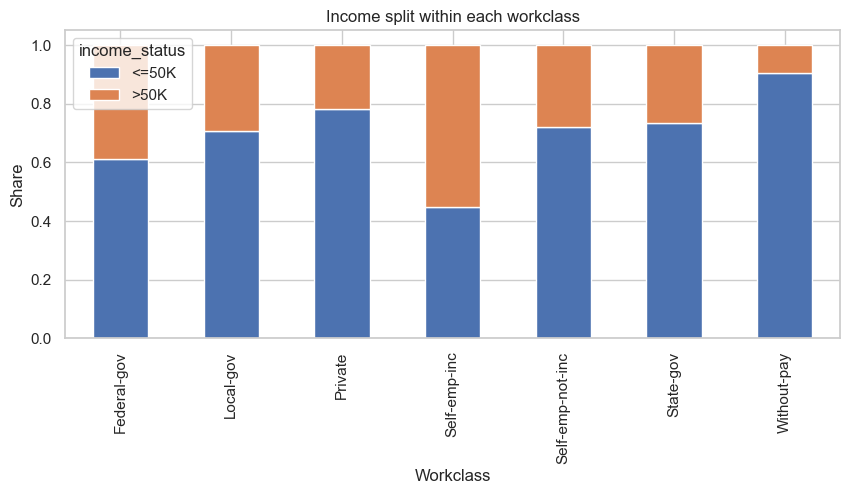

In [28]:
# Graficar proporciones
tabla_wc_income_prop.plot(kind="bar", stacked=True, figsize=(10, 4))
# Titulos
plt.title("Income split within each workclass")
# Ejes
plt.xlabel("Workclass")
# Ejes
plt.ylabel("Share")
# Mostrar
plt.show()

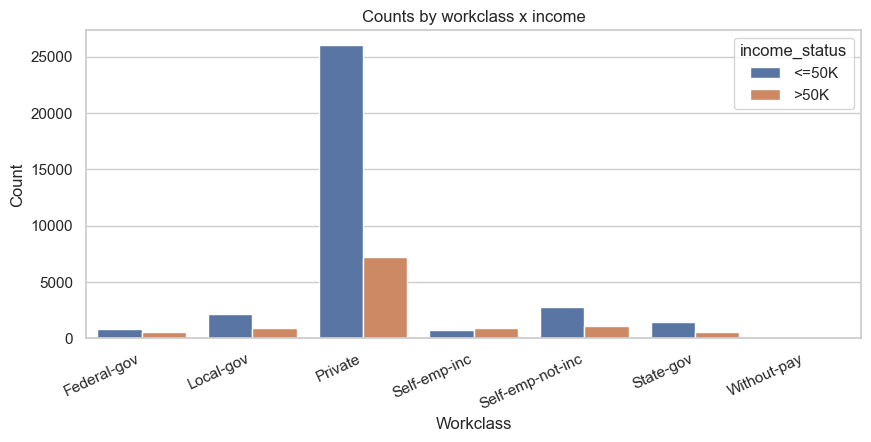

In [29]:
# Barras lado a lado (frecuencia absoluta)
plt.figure(figsize=(10, 4))
sns.countplot(data=data, x="workclass", hue="income_status")
plt.title("Counts by workclass x income")
plt.xlabel("Workclass")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.show()

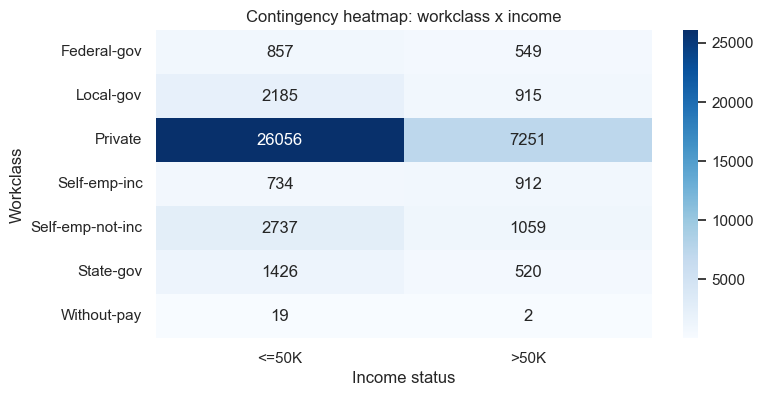

In [30]:
# Heatmap de contingencia
plt.figure(figsize=(8, 4))
sns.heatmap(tabla_wc_income, annot=True, fmt="d", cmap="Blues")
plt.title("Contingency heatmap: workclass x income")
plt.xlabel("Income status")
plt.ylabel("Workclass")
plt.show()

## 5) Categorica vs numerica

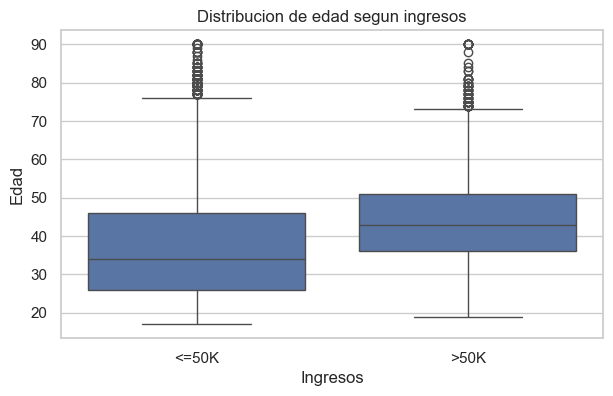

In [31]:
# Boxplot de edad segun ingreso
plt.figure(figsize=(7, 4))
sns.boxplot(data=data, x="income_status", y="age")
plt.title("Distribucion de edad segun ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Edad")
plt.show()

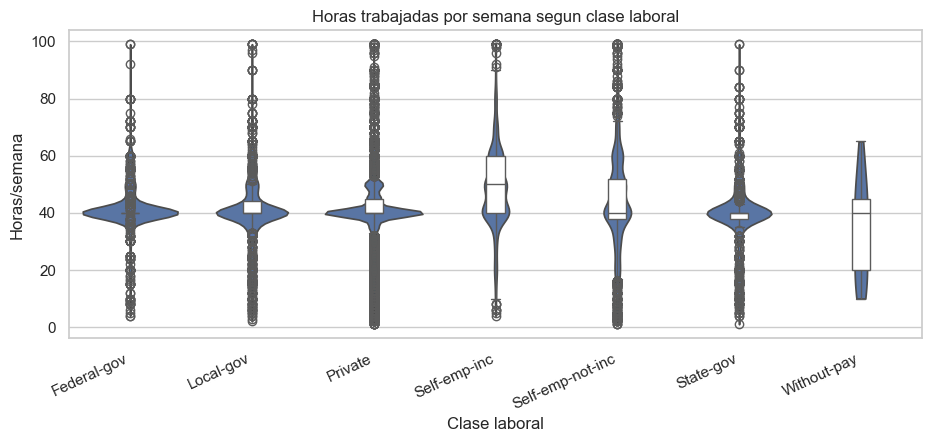

In [32]:
# Violin + boxplot de horas por clase laboral
plt.figure(figsize=(11, 4))
sns.violinplot(data=data, x="workclass", y="hours_per_week", inner=None, cut=0)
sns.boxplot(data=data, x="workclass", y="hours_per_week", width=0.15, showcaps=True, boxprops={"facecolor": "white"})
plt.title("Horas trabajadas por semana segun clase laboral")
plt.xlabel("Clase laboral")
plt.ylabel("Horas/semana")
plt.xticks(rotation=25, ha="right")
plt.show()

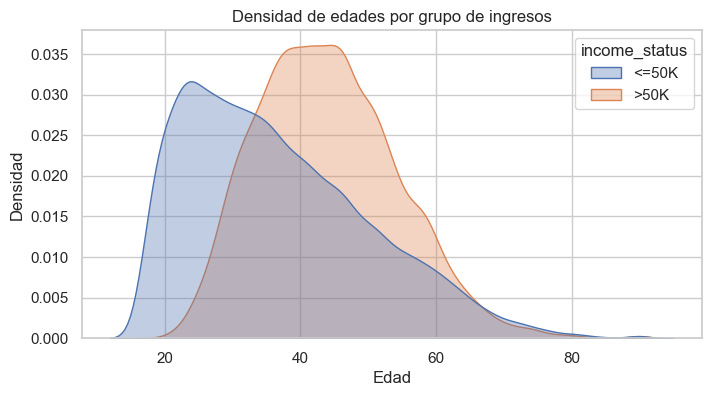

In [33]:
# Densidad de edad por grupo de ingresos
plt.figure(figsize=(8, 4))
sns.kdeplot(data=data, x="age", hue="income_status", fill=True, common_norm=False, alpha=0.35)
plt.title("Densidad de edades por grupo de ingresos")
plt.xlabel("Edad")
plt.ylabel("Densidad")
plt.show()

## 6) Numerica vs numerica

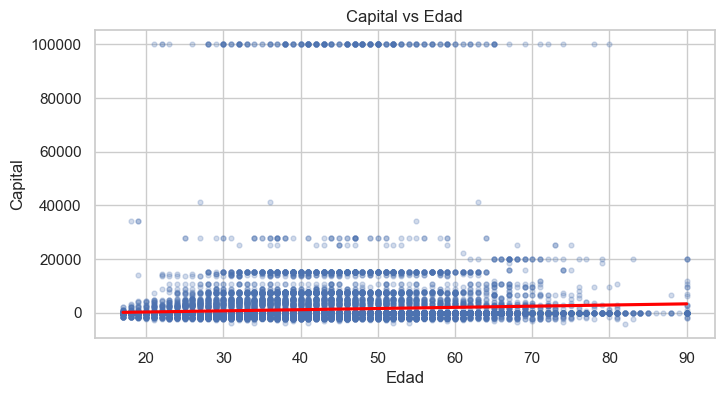

In [34]:
# Dispersión con recta de tendencia
plt.figure(figsize=(8, 4))
sns.regplot(data=data, x="age", y="capital", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"})
plt.title("Capital vs Edad")
plt.xlabel("Edad")
plt.ylabel("Capital")
plt.show()

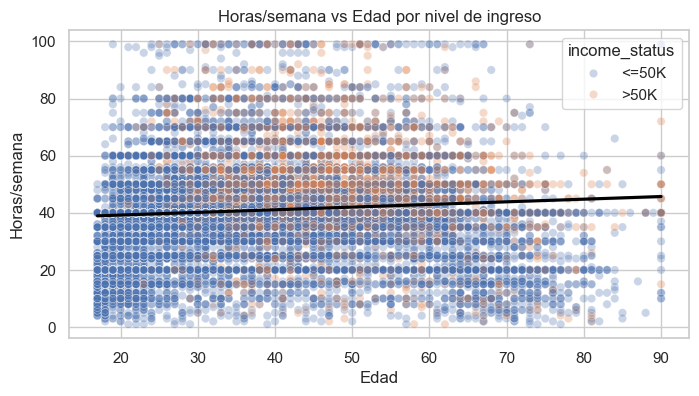

In [35]:
# Dispersión coloreada por ingreso
plt.figure(figsize=(8, 4))
sns.scatterplot(data=data, x="age", y="hours_per_week", hue="income_status", alpha=0.3)
sns.regplot(data=data, x="age", y="hours_per_week", scatter=False, color="black")
plt.title("Horas/semana vs Edad por nivel de ingreso")
plt.xlabel("Edad")
plt.ylabel("Horas/semana")
plt.show()

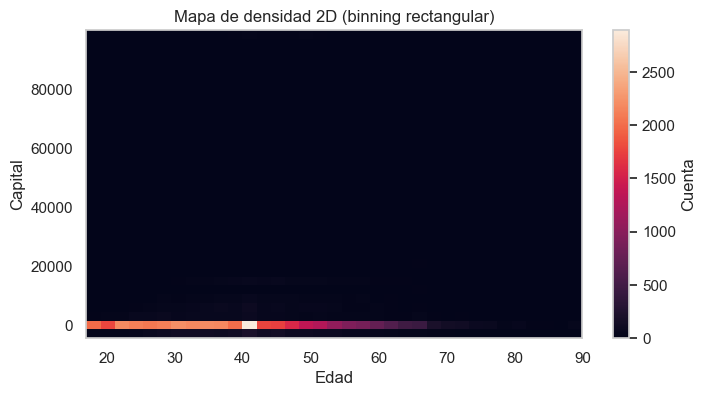

In [36]:
# Densidad 2D con bins rectangulares
plt.figure(figsize=(8, 4))
plt.hist2d(data["age"], data["capital"], bins=35)
plt.colorbar(label="Cuenta")
plt.title("Mapa de densidad 2D (binning rectangular)")
plt.xlabel("Edad")
plt.ylabel("Capital")
plt.show()

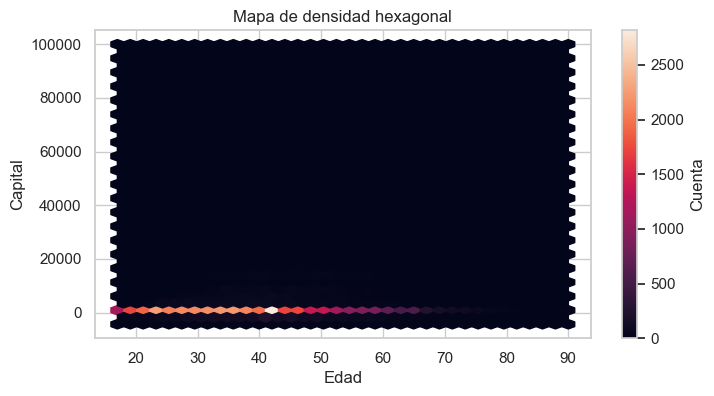

In [37]:
# Densidad 2D con hexagono
plt.figure(figsize=(8, 4))
plt.hexbin(data["age"], data["capital"], gridsize=35)
plt.colorbar(label="Cuenta")
plt.title("Mapa de densidad hexagonal")
plt.xlabel("Edad")
plt.ylabel("Capital")
plt.show()

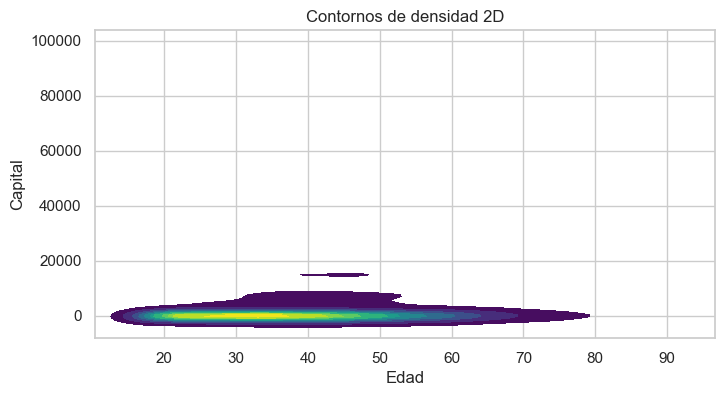

In [38]:
# Contornos de densidad 2D
plt.figure(figsize=(8, 4))
sns.kdeplot(data=data, x="age", y="capital", fill=True, cmap="viridis", levels=12, thresh=0.05)
plt.title("Contornos de densidad 2D")
plt.xlabel("Edad")
plt.ylabel("Capital")
plt.show()